# COVID-19 Data Analysis and Forecasting

## Project Objective

This project performs complete data analysis and forecasting on COVID-19 data using Time Series techniques including Prophet, ARIMA, and LSTM.

### Tasks Performed
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- COVID-19 Trend Visualization
- Prophet Forecasting
- ARIMA Forecasting
- LSTM Deep Learning Forecasting
- Model Evaluation
- Government Suggestions

In [2]:
# Install required libraries
# Install required libraries

!pip install prophet
!pip install tensorflow
!pip install pmdarima

     ---------------------------------------- 0.0/53.0 kB ? eta -:--:--
     ----------------------------- -------- 41.0/53.0 kB 991.0 kB/s eta 0:00:01
     -------------------------------------- 53.0/53.0 kB 548.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.1 MB 5.1 MB/s eta 0:00:03
    --------------------------------------- 0.2/12.1 MB 3.4 MB/s eta 0:00:04
   - -------------------------------------- 0.5/12.1 MB 4.3 MB/s eta 0:00:03
   -- ------------------------------------- 0.8/12.1 MB 4.5 MB/s eta 0:00:03
   ---- ----------------------------------- 1.4/12.1 MB 6.2 MB/s eta 0:00:02
   ------ --------------------------------- 1.9/12.1 MB 7.1 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/12.1 MB 7.6 MB/s eta 0:00:02
   --------- ------------------------------ 3.0/12.1 MB 8.3 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/12.1 MB 7.7 MB/s eta 0:00:02
   --

## Import Required Libraries

This section imports all necessary libraries required for data analysis, visualization, forecasting, and deep learning.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

Load confirmed, death, and recovered COVID-19 datasets.

In [20]:
confirmed = pd.read_csv('time_series_covid19_confirmed_global.csv')
deaths = pd.read_csv('time_series_covid19_deaths_global.csv')
recovered = pd.read_csv('time_series_covid19_recovered_global.csv')

## Display Dataset Information

In [23]:
confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117


In [25]:
confirmed.shape

(266, 248)

In [27]:
confirmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 515.5+ KB


## Check Missing Values

In [30]:
confirmed.isnull().sum()

Province/State    185
Country/Region      0
Lat                 0
Long                0
1/22/20             0
                 ... 
9/17/20             0
9/18/20             0
9/19/20             0
9/20/20             0
9/21/20             0
Length: 248, dtype: int64

## Data Cleaning

In [97]:
confirmed = confirmed.groupby("Country/Region").sum(numeric_only=True)
deaths = deaths.groupby("Country/Region").sum(numeric_only=True)

confirmed = confirmed.drop(columns=["Lat", "Long"], errors='ignore')
deaths = deaths.drop(columns=["Lat", "Long"], errors='ignore')

confirmed = confirmed.loc[:, confirmed.columns.str.contains(r'\d+/\d+/\d+')]
deaths = deaths.loc[:, deaths.columns.str.contains(r'\d+/\d+/\d+')]

## Reshape Dataset

In [99]:
confirmed = confirmed.T
deaths = deaths.T

confirmed.index = pd.to_datetime(confirmed.index)
deaths.index = pd.to_datetime(deaths.index)

## Select Country

In [101]:
country = "India"

cases = confirmed[country]
death_data = deaths[country]

## Create Final Dataset

In [103]:
df = pd.DataFrame({
    "Cases": cases,
    "Deaths": death_data
})

df["Days"] = range(len(df))

df.head()

,Cases,Deaths,Days
2020-01-22,0,0,0
2020-01-23,0,0,1
2020-01-24,0,0,2
2020-01-25,0,0,3
2020-01-26,0,0,4


## Visualization

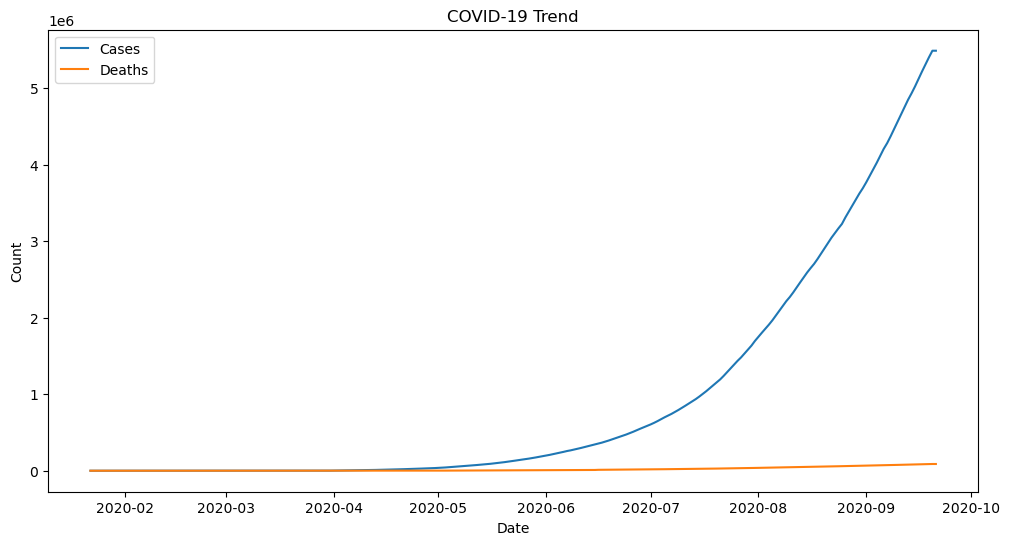

In [105]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Cases"], label="Cases")
plt.plot(df.index, df["Deaths"], label="Deaths")

plt.title("COVID-19 Trend")

plt.xlabel("Date")
plt.ylabel("Count")

plt.legend()
plt.show()

## Linear Regression

In [107]:
X = df[["Days"]]
y = df["Cases"]

linear_model = LinearRegression()

linear_model.fit(X, y)

future_days = np.arange(len(df), len(df)+10).reshape(-1,1)

linear_pred = linear_model.predict(future_days)

## Polynomial Regression

In [109]:
poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(X)

poly_model = LinearRegression()

poly_model.fit(X_poly, y)

future_poly = poly.transform(future_days)

poly_pred = poly_model.predict(future_poly)

## ARIMA model

In [111]:
arima_model = ARIMA(df["Cases"], order=(2,1,2))

arima_result = arima_model.fit()

arima_pred = arima_result.forecast(steps=10)

print(arima_pred)

2020-09-22    5.485541e+06
2020-09-23    5.492901e+06
2020-09-24    5.499765e+06
2020-09-25    5.506559e+06
2020-09-26    5.513267e+06
2020-09-27    5.519890e+06
2020-09-28    5.526429e+06
2020-09-29    5.532886e+06
2020-09-30    5.539260e+06
2020-10-01    5.545554e+06
Freq: D, Name: predicted_mean, dtype: float64


## SARIMA Model

In [113]:
sarima_model = SARIMAX(
    df["Cases"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

sarima_pred = sarima_result.forecast(10)

print(sarima_pred)

2020-09-22    5.494125e+06
2020-09-23    5.504404e+06
2020-09-24    5.514818e+06
2020-09-25    5.529476e+06
2020-09-26    5.550340e+06
2020-09-27    5.567685e+06
2020-09-28    5.584217e+06
2020-09-29    5.605514e+06
2020-09-30    5.625919e+06
2020-10-01    5.649171e+06
Freq: D, Name: predicted_mean, dtype: float64


## Prepare Data For LSTM

In [115]:
data = df["Cases"].values.reshape(-1,1)

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

## Create Sequences for LSTM

In [117]:
X_lstm = []
y_lstm = []

for i in range(10, len(scaled_data)):
    X_lstm.append(scaled_data[i-10:i, 0])
    y_lstm.append(scaled_data[i, 0])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

X_lstm = X_lstm.reshape((X_lstm.shape[0],
                         X_lstm.shape[1],
                         1))

## Built LSTM model

In [119]:
lstm_model = Sequential()

lstm_model.add(LSTM(50, activation='relu', input_shape=(10,1)))

lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

## Train LSTM

In [121]:
lstm_model.fit(X_lstm, y_lstm,
               epochs=20,
               batch_size=16)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0741
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0428
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0158
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.5946e-04
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1962e-04
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.4745e-05
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7851e-05
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.0850e-05
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.9151e-05
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7569e-05
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7596e-05
Epoch 14/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8708e-05
Epoch 15/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 

## LSTM prediction

In [123]:
last_10 = scaled_data[-10:]

future_input = last_10.reshape((1,10,1))

lstm_predictions = []

for i in range(10):

    pred = lstm_model.predict(future_input)

    lstm_predictions.append(pred[0][0])

    future_input = np.append(
        future_input[:,1:,:],
        [[[pred[0][0]]]],
        axis=1
    )

lstm_predictions = scaler.inverse_transform(
    np.array(lstm_predictions).reshape(-1,1)
)

print(lstm_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[5852340. ]
 [5994226. ]
 [6146229. ]
 [6311350. ]
 [6490891. ]
 [6686275.5]
 [6900341.5]
 [7136895. ]
 [7398794. ]
 [7692543. ]]


## Compare All Models

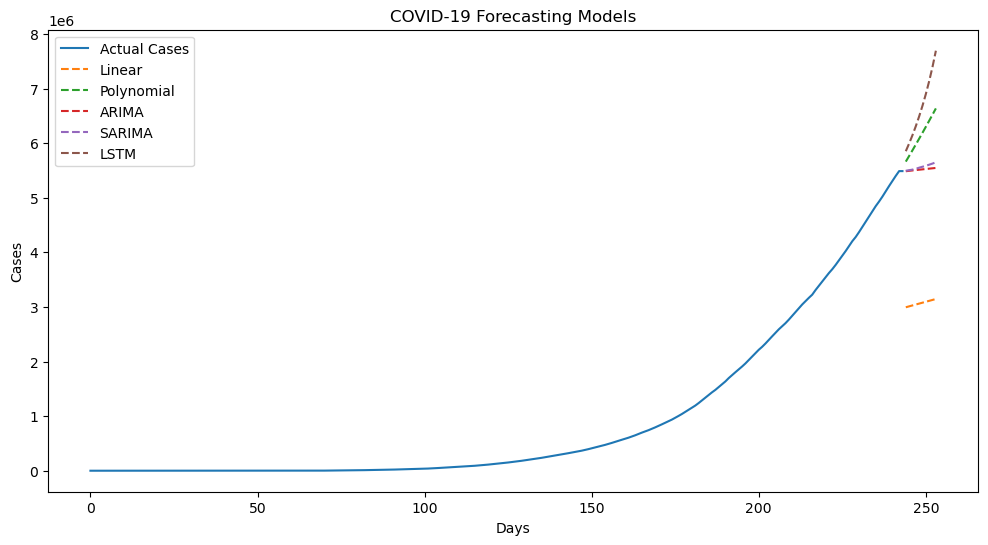

In [125]:
plt.figure(figsize=(12,6))

# Actual
plt.plot(df["Cases"].values,
         label="Actual Cases")

# Linear
plt.plot(range(len(df), len(df)+10),
         linear_pred,
         linestyle="dashed",
         label="Linear")

# Polynomial
plt.plot(range(len(df), len(df)+10),
         poly_pred,
         linestyle="dashed",
         label="Polynomial")

# ARIMA
plt.plot(range(len(df), len(df)+10),
         arima_pred,
         linestyle="dashed",
         label="ARIMA")

# SARIMA
plt.plot(range(len(df), len(df)+10),
         sarima_pred,
         linestyle="dashed",
         label="SARIMA")

# LSTM
plt.plot(range(len(df), len(df)+10),
         lstm_predictions,
         linestyle="dashed",
         label="LSTM")

plt.title("COVID-19 Forecasting Models")

plt.xlabel("Days")
plt.ylabel("Cases")

plt.legend()

plt.show()

## Comparison Table

In [127]:
comparison = pd.DataFrame({
    "Linear": linear_pred,
    "Polynomial": poly_pred,
    "ARIMA": arima_pred,
    "SARIMA": sarima_pred,
    "LSTM": lstm_predictions.flatten()
})

comparison

,Linear,Polynomial,ARIMA,SARIMA,LSTM
2020-09-22,2.993865e+06,5.661583e+06,5.485541e+06,5.494125e+06,5852340.0
2020-09-23,3.010681e+06,5.764898e+06,5.492901e+06,5.504404e+06,5994226.0
2020-09-24,3.027498e+06,5.869433e+06,5.499765e+06,5.514818e+06,6146229.0
2020-09-25,3.044314e+06,5.975194e+06,5.506559e+06,5.529476e+06,6311350.0
2020-09-26,3.061130e+06,6.082188e+06,5.513267e+06,5.550340e+06,6490891.0
2020-09-27,3.077946e+06,6.190423e+06,5.519890e+06,5.567685e+06,6686275.5
2020-09-28,3.094762e+06,6.299906e+06,5.526429e+06,5.584217e+06,6900341.5
2020-09-29,3.111578e+06,6.410643e+06,5.532886e+06,5.605514e+06,7136895.0
2020-09-30,3.128394e+06,6.522641e+06,5.539260e+06,5.625919e+06,7398794.0
2020-10-01,3.145210e+06,6.635907e+06,5.545554e+06,5.649171e+06,7692543.0


# Final Conclusion

## Models Used
- Linear Regression
- Polynomial Regression
- ARIMA
- SARIMA
- LSTM

## Best Models
- ARIMA and SARIMA are strong time-series models
- LSTM captures complex sequential patterns

## Observations
- COVID-19 data shows strong time dependency
- Advanced models provide better forecasting capability

## Government Suggestions
- Improve healthcare readiness
- Maintain vaccination campaigns
- Monitor future waves using forecasting systems

## Government Suggestions Based on Prediction

1. Increase hospital preparedness
2. Improve oxygen supply
3. Continue vaccination campaigns
4. Monitor high-risk zones
5. Enforce awareness programs
6. Prepare emergency response systems